# Student Performance (score) Predition : Regression
- Data Source: https://www.kaggle.com/datasets/amrmaree/student-performance-prediction?resource=download


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Reading & Understanding Data

In [101]:
df = pd.read_csv("student_performance_dataset.csv")
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


In [102]:
df.columns

Index(['Student_ID', 'Gender', 'Study_Hours_per_Week', 'Attendance_Rate',
       'Past_Exam_Scores', 'Parental_Education_Level',
       'Internet_Access_at_Home', 'Extracurricular_Activities',
       'Final_Exam_Score', 'Pass_Fail'],
      dtype='object')

In [ ]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 708 entries, 0 to 707
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  708 non-null    object 
 1   Gender                      708 non-null    object 
 2   Study_Hours_per_Week        708 non-null    int64  
 3   Attendance_Rate             708 non-null    float64
 4   Past_Exam_Scores            708 non-null    int64  
 5   Parental_Education_Level    708 non-null    object 
 6   Internet_Access_at_Home     708 non-null    object 
 7   Extracurricular_Activities  708 non-null    object 
 8   Final_Exam_Score            708 non-null    int64  
 9   Pass_Fail                   708 non-null    object 
dtypes: float64(1), int64(3), object(6)
memory usage: 55.4+ KB


In [104]:
df.shape

(708, 10)

## 2. Handling Missing values (EDA)

In [ ]:
df.isnull().sum() 

Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

    No Missing values found

## 3. Encoding
### Label, One Hot Encoding , Binary Encoding
Example with Condition = {Excellent, Good, Fair, Poor}:

1. Label Encoding → {Excellent=3, Good=2, Fair=1, Poor=0} (order matters).
2. One-Hot → 4 new columns (Excellent, Good, Fair, Poor).
3. Dummy Variables → 3 columns only (drop one).
4. Binary → If only “Good” or “Bad” → {Good=1, Bad=0}.

In [ ]:
df.head() 

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,Male,31,68.267841,86,High School,Yes,Yes,63,Pass
1,S136,Male,16,78.222927,73,PhD,No,No,50,Fail
2,S209,Female,21,87.525096,74,PhD,Yes,No,55,Fail
3,S458,Female,27,92.076483,99,Bachelors,No,No,65,Pass
4,S078,Female,37,98.655517,63,Masters,No,Yes,70,Pass


### Columns Need to be Encoded

1. Gender: Binary Encoding (BE)
2. Pass_Fail: Binary Encoding (BE)
3. Extracurricular_Activities : Binary Encoding (BE)
4. Internet_Access_at_Home: Binary Encoding (BE)
5. Parental_Education_Level : Label Encoding 

#### Binary Encoding (BE)

In [107]:
df["Gender"] = df["Gender"].map({'Male':1, 'Female':0})
df["Pass_Fail"] = df["Pass_Fail"].map({"Pass":1, "Fail":0})
df["Extracurricular_Activities"] = df["Extracurricular_Activities"].map({"Yes":1, "No":0})
df["Internet_Access_at_Home"] = df["Internet_Access_at_Home"].map({"Yes":1, "No":0})


#### Label Encoding

In [108]:
## Getting Unique Values
df["Parental_Education_Level"].unique()

array(['High School', 'PhD', 'Bachelors', 'Masters'], dtype=object)

In [109]:
edu_order = {
    "High School":1,
    "Bachelors":2,
    "Masters":3,
    "PhD":4
}


df["Parental_Education_Level"] = df["Parental_Education_Level"].map(edu_order)

In [110]:
df.head()

,Student_ID,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,S147,1,31,68.267841,86,1,1,1,63,1
1,S136,1,16,78.222927,73,4,0,0,50,0
2,S209,0,21,87.525096,74,4,1,0,55,0
3,S458,0,27,92.076483,99,2,0,0,65,1
4,S078,0,37,98.655517,63,3,0,1,70,1


    All Columns are Encoded

In [111]:
df.isnull().sum()

Student_ID                    0
Gender                        0
Study_Hours_per_Week          0
Attendance_Rate               0
Past_Exam_Scores              0
Parental_Education_Level      0
Internet_Access_at_Home       0
Extracurricular_Activities    0
Final_Exam_Score              0
Pass_Fail                     0
dtype: int64

## 4. Feature Slection
- Target Variable : y
- Input Variables: X

##### SO
- Our Target Variable is (y): (Final_Exam_Score)
- Input Variables (X) : 
    -  Gender	
    - Study_Hours_per_Week
    - Attendance_Rate
    - Past_Exam_Scores	
    - Parental_Education_Level	
    - Internet_Access_at_Home	
    - Extracurricular_Activities	
    - Final_Exam_Score	
    - Pass_Fail

    

In [112]:
df = df.drop("Student_ID", axis=1) # axis 1 for column

In [113]:
df.head()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Final_Exam_Score,Pass_Fail
0,1,31,68.267841,86,1,1,1,63,1
1,1,16,78.222927,73,4,0,0,50,0
2,0,21,87.525096,74,4,1,0,55,0
3,0,27,92.076483,99,2,0,0,65,1
4,0,37,98.655517,63,3,0,1,70,1


####  Target Variables: (y) & Input Variables(y)

In [ ]:
y = df["Final_Exam_Score"] # Target Variable
X = df.drop("Final_Exam_Score", axis=1)

In [115]:
y.head()

0    63
1    50
2    55
3    65
4    70
Name: Final_Exam_Score, dtype: int64

In [116]:
X.head()

,Gender,Study_Hours_per_Week,Attendance_Rate,Past_Exam_Scores,Parental_Education_Level,Internet_Access_at_Home,Extracurricular_Activities,Pass_Fail
0,1,31,68.267841,86,1,1,1,1
1,1,16,78.222927,73,4,0,0,0
2,0,21,87.525096,74,4,1,0,0
3,0,27,92.076483,99,2,0,0,1
4,0,37,98.655517,63,3,0,1,1


## 5. Features Scaling: (X,y)
- Input variable scaling

In [117]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 6. Train, Test, Split
-  Train-test split (80% train, 20% test)

In [118]:
# from sklearn.model_selection import train_test_split
# X_train, X_test, y_train, y_test = train_test_split(
#     X_scaled, y, test_size=0.2, random_state=42
# )

# print("Train shape:", X_train.shape, y_train.shape)
# print("Test shape:", X_test.shape, y_test.shape)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# separate scalers for X and y
scaler_X = StandardScaler()
scaler_y = StandardScaler()

# scale features
X_scaled = scaler_X.fit_transform(X)

# scale target (must reshape to 2D)
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))

# split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)


Train shape: (566, 8) (566, 1)
Test shape: (142, 8) (142, 1)


## 7. Model Selection & Training

In [119]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
# ✅ Predict on test data
y_pred_test = model.predict(X_test)

y_pred_test 

array([[-1.51135929],
       [ 1.03255225],
       [ 1.06747571],
       [ 0.98210819],
       [ 0.92484202],
       [-0.78009813],
       [ 1.11380703],
       [-1.00123575],
       [-0.71987005],
       [-1.01992825],
       [ 0.89002284],
       [ 0.88712161],
       [ 1.35021686],
       [-0.38459429],
       [-1.15558435],
       [-0.94758231],
       [ 0.92668682],
       [-0.99553521],
       [ 0.65388045],
       [-1.47788019],
       [ 0.94487698],
       [-1.04247355],
       [-0.94798372],
       [-0.89591868],
       [ 0.8502324 ],
       [-0.8960071 ],
       [ 0.89002284],
       [-0.43427557],
       [ 1.07735913],
       [-0.81566209],
       [-0.39845062],
       [ 0.65417235],
       [ 1.09240546],
       [-0.83137434],
       [-1.12796748],
       [-1.27810733],
       [-1.06745124],
       [-0.43191944],
       [ 0.9324513 ],
       [ 0.73494453],
       [-0.79554124],
       [ 0.94487698],
       [ 0.9324513 ],
       [ 1.18343977],
       [-1.41784022],
       [ 0

## 8. Model Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))
print(model.score(X_test, y_test))

MAE: 0.321175990154569
MSE: 0.14972471118122696
RMSE: 0.38694277507304226
R² Score: 0.8419689321874301
0.8419689321874301


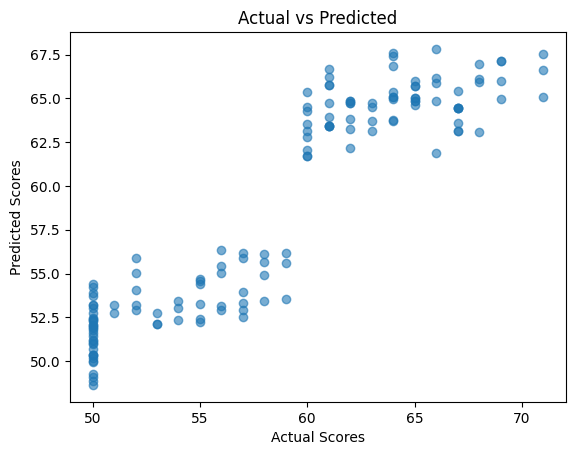

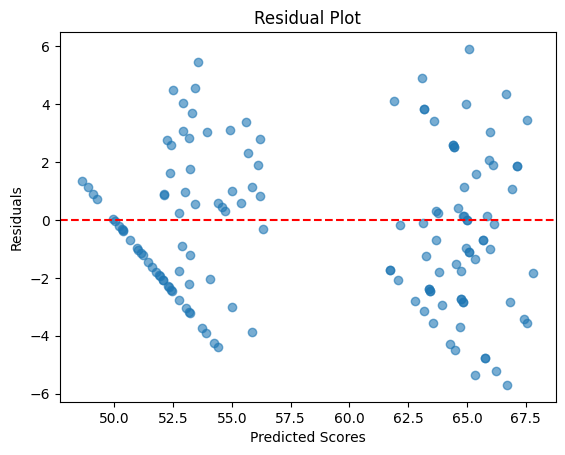

In [ ]:
# inverse transform both y_test and predictions
y_test_orig = scaler_y.inverse_transform(y_test)
y_pred_orig = scaler_y.inverse_transform(y_pred)

# Actual vs Predicted
plt.scatter(y_test_orig, y_pred_orig, alpha=0.6)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.show()

# Residual plot
residuals = y_test_orig - y_pred_orig
plt.scatter(y_pred_orig, residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show() 

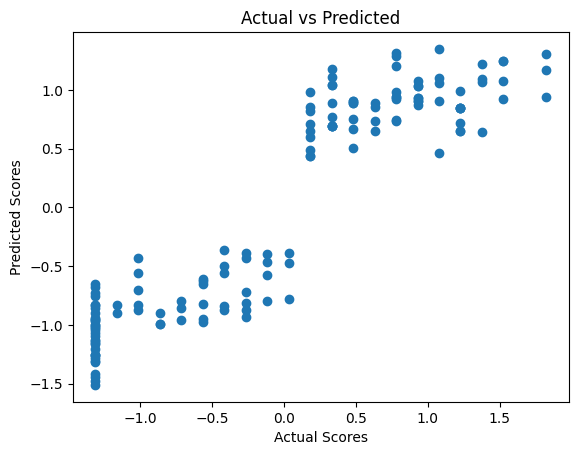

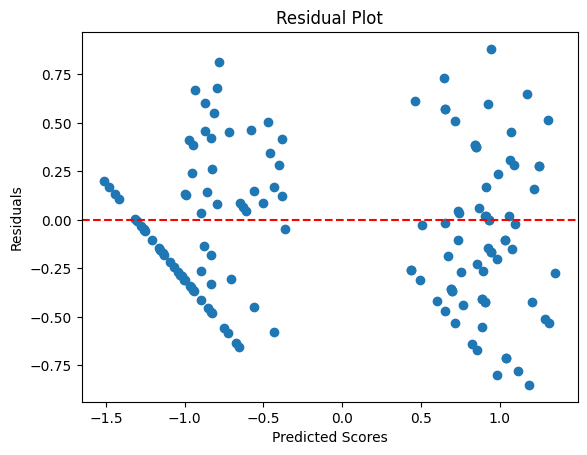

In [123]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Scores")
plt.ylabel("Predicted Scores")
plt.title("Actual vs Predicted")
plt.show()

# Residual plot
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted Scores")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()


## 09. Save Model

In [124]:
from sklearn.linear_model import LinearRegression
import joblib
joblib.dump(model,'Trained_Models/std_perf.joblib')


['Trained_Models/std_perf.joblib']

In [126]:
#  Load Model
md1 = joblib.load('Trained_Models/std_perf.joblib')
# feature = [0,37,98.655517,63,3,0,1,1]
feature = [0	,37	,98.655517,	63,	3	,0	,1,	1] # 70
# feature = [1,	31	,68.267841	,86	,1	,1	,1	,1 ]# 63
# feature = [1,	16,	78.222927	,73	,4	,0	,0	,0] # 50

def predict_score(model, features):
    
    

    output = int(model.predict([feature]))  
    return f"Predicted Price in PKR:{output}"
    # return output # Returns scalar

    # Example usage
predict_score(md1, feature)

C:\Users\aabidkhokhar\AppData\Local\Temp\ipykernel_10836\4070111807.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  output = int(model.predict([feature]))


'Predicted Price in PKR:42'